In [52]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from scipy.optimize import curve_fit

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from functions.read_g4bl_data import readTraceData
from functions.set_plot_settings import setPlotSettings

setPlotSettings(font=True)

## p = 247.5 MeV/c

In [43]:
data = readTraceData('ReferenceParticle.txt')

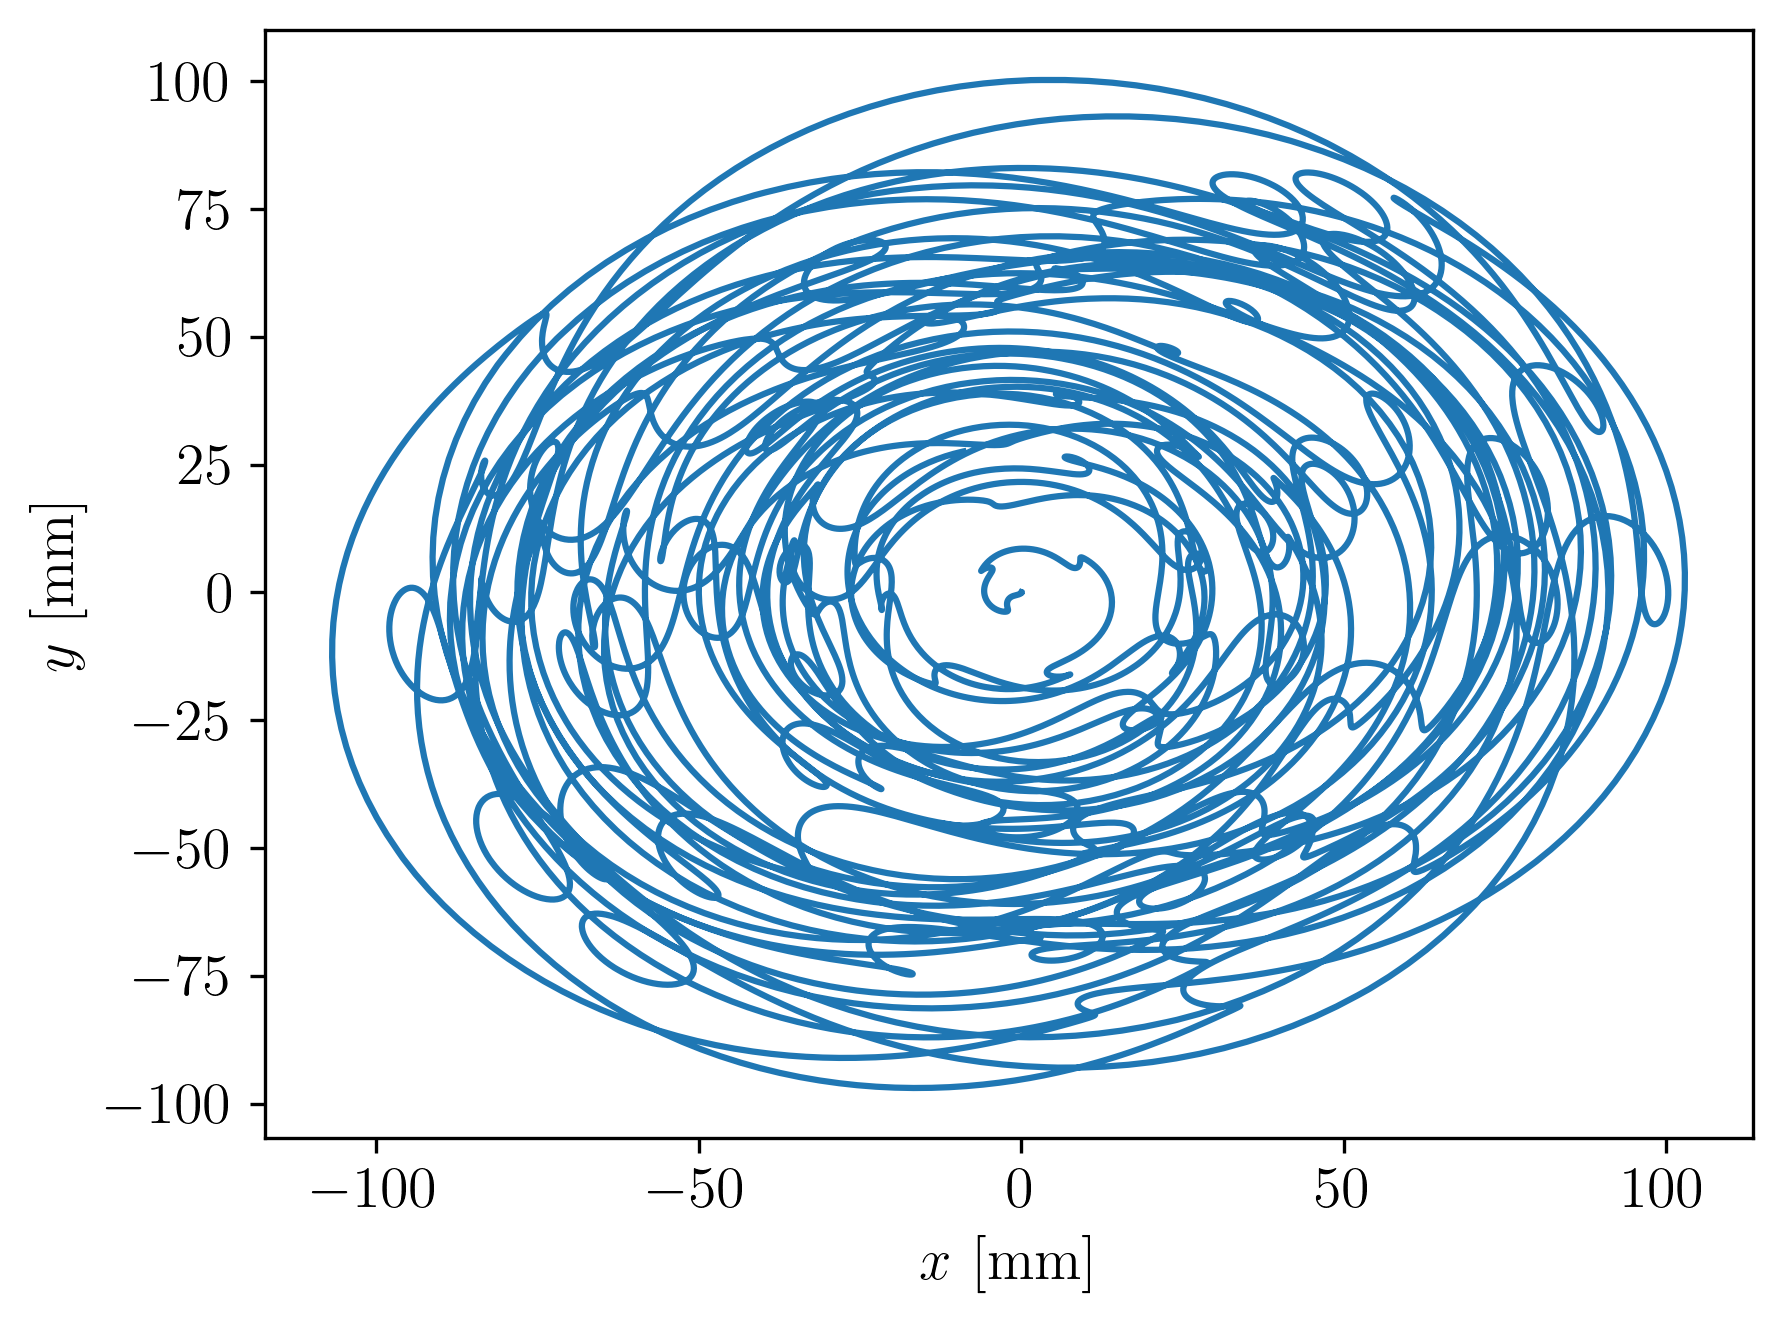

In [44]:
plt.plot(data['x'], data['y'])
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');

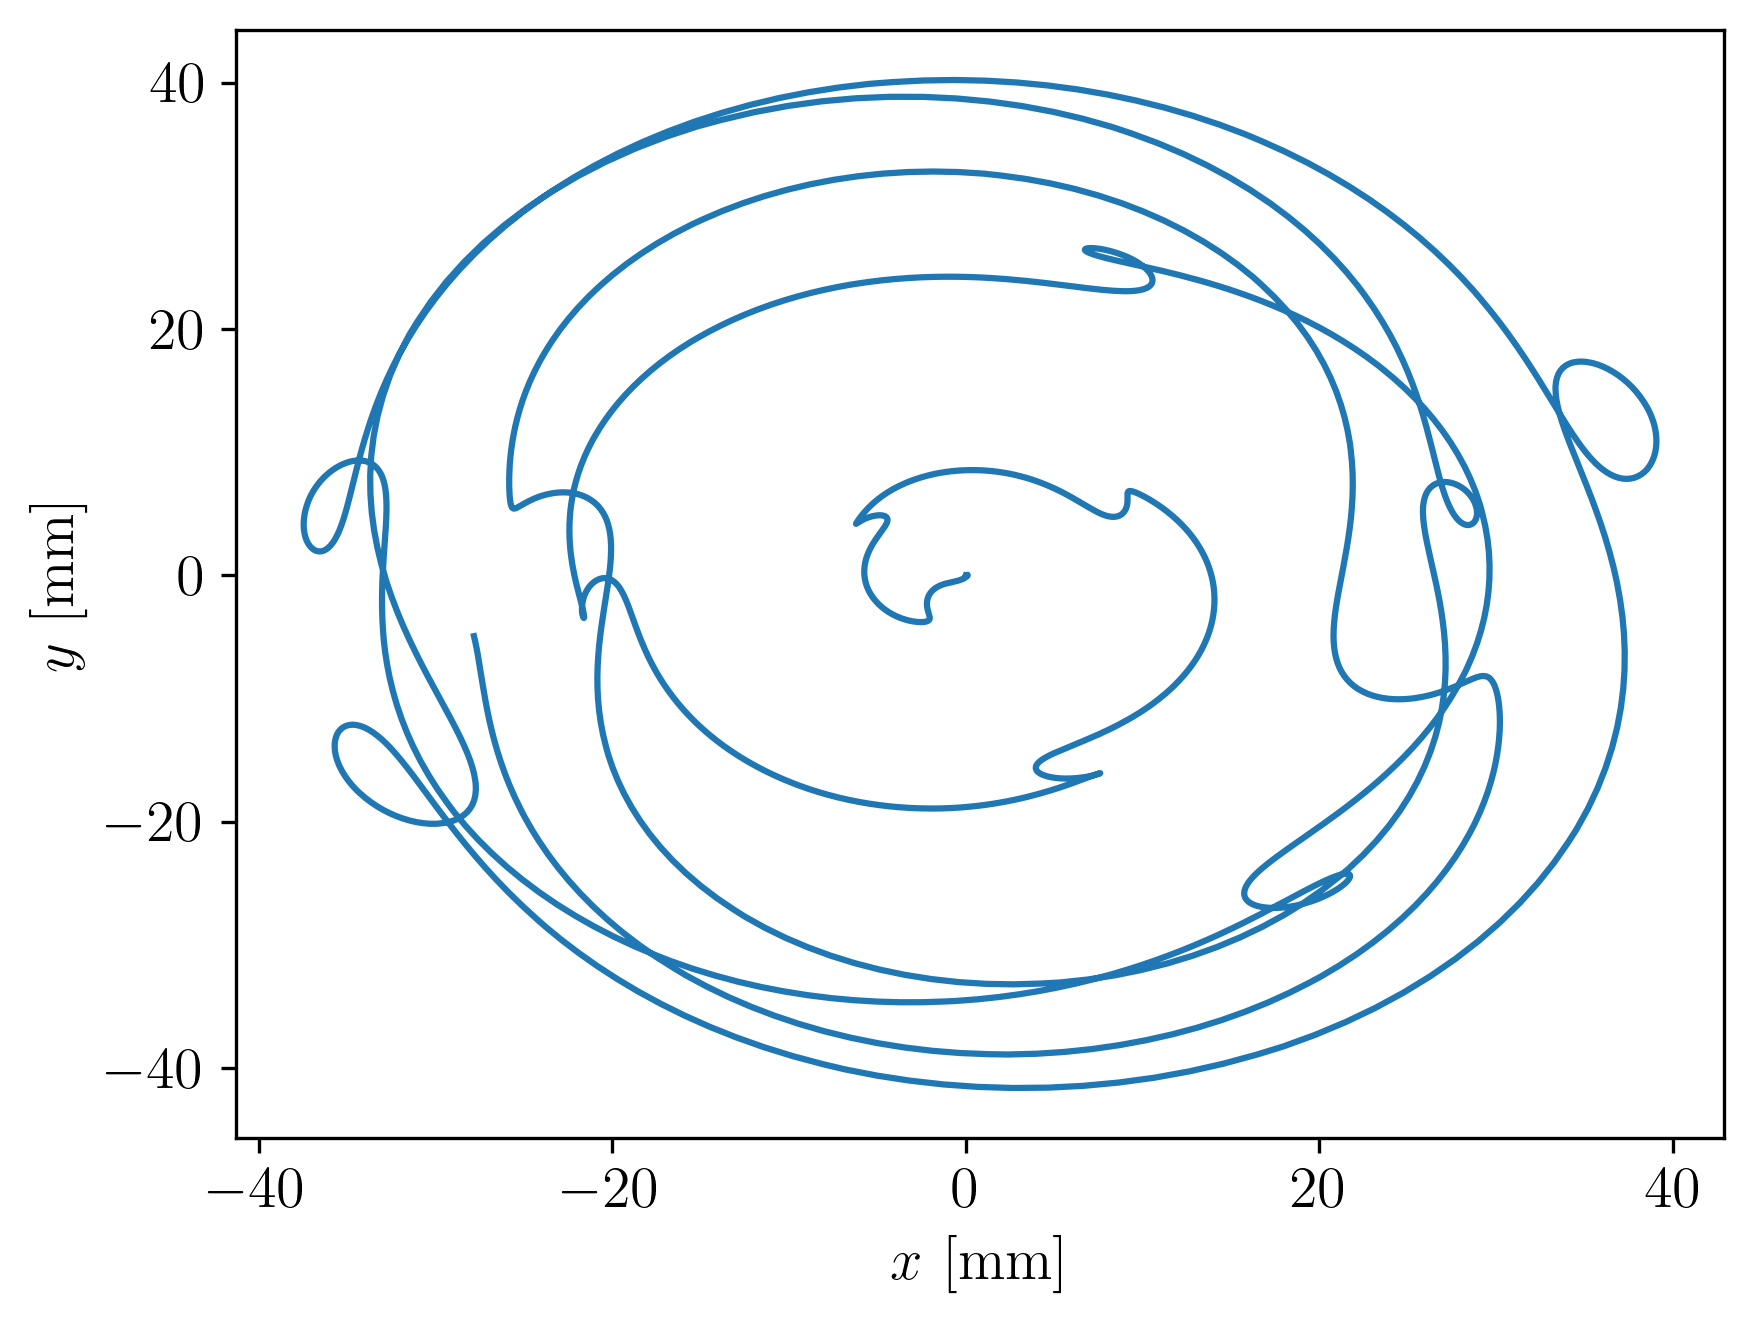

In [45]:
cut = 2500
plt.plot(data['x'][:cut], data['y'][:cut])
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');

## p = 221.8 MeV/c

In [46]:
data2 = readTraceData('ReferenceParticle2.txt')

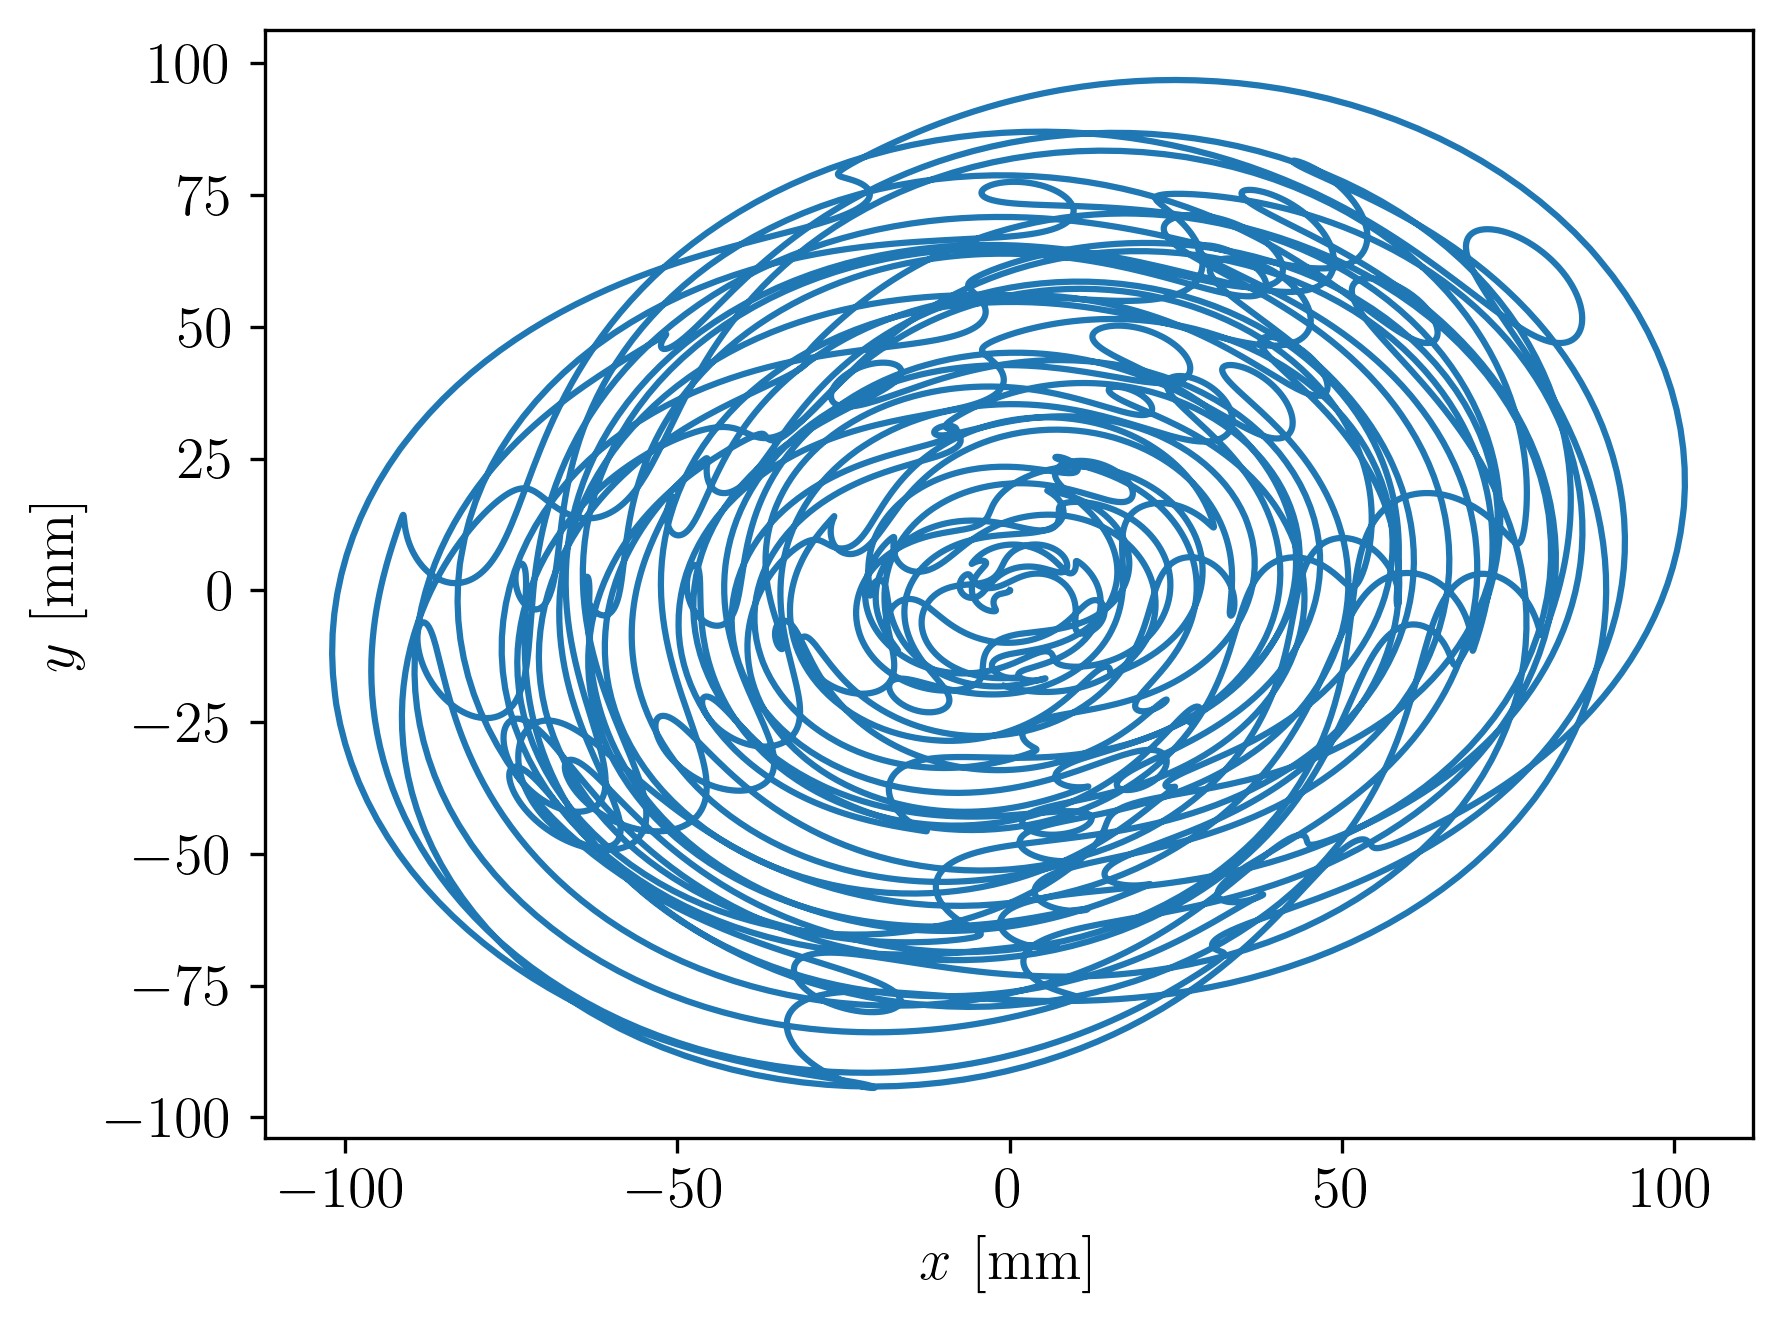

In [47]:
plt.plot(data2['x'], data2['y'])
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');

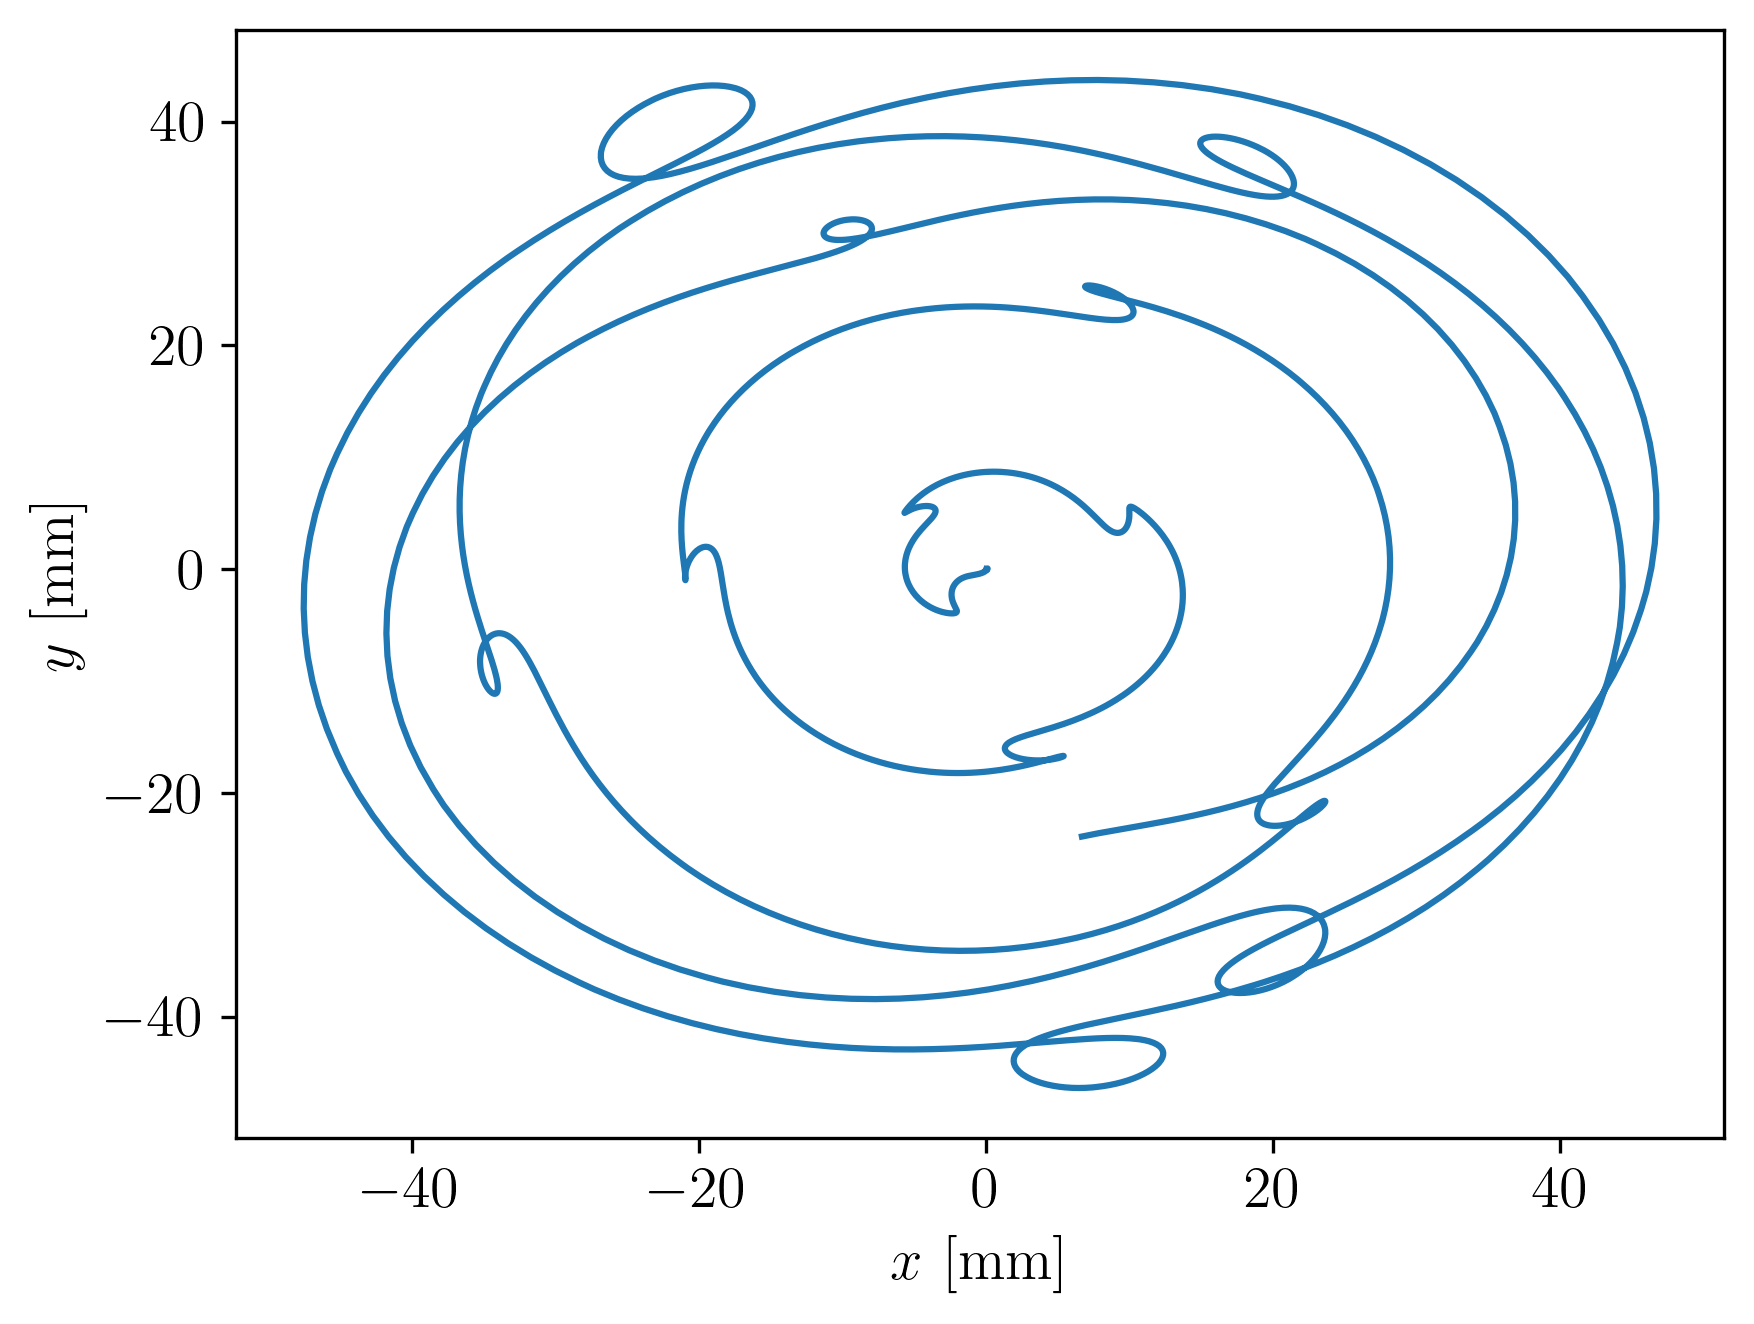

In [48]:
cut = 2500
plt.plot(data2['x'][:cut], data2['y'][:cut])
plt.xlabel('$x$ [mm]')
plt.ylabel('$y$ [mm]');

## Field map

In [66]:
def readFieldMapData(file):

    ''' Returns a DataFrame with positions, time, and magnetic field components. From the fieldntuple G4bl command.

    The default units are mm for position and Tesla for B field.
    
    Inputs:
    file = G4beamline output file from fieldntuple (ascii) '''
    
    data = np.loadtxt(file)
    
    columns = ['x', 'y', 'z', 't', 'Bx', 'By', 'Bz', 'Ex', 'Ey', 'Ez']
    df = pd.DataFrame(data[:, 0:10], columns=columns)

    theta = np.arctan2(df['y'], df['x'])
    df['Br'] = df['Bx']*np.cos(theta) + df['By']*np.sin(theta)

    return df

In [67]:
vals = readFieldMapData('fieldmap.txt')

In [68]:
vals

,x,y,z,t,Bx,By,Bz,Ex,Ey,Ez,Br
0,0.0,0.0,1075.0,5.40,-0.000007,-0.000207,-2.96394,0.0,0.0,-12.31310,-0.000007
1,0.0,0.0,1075.0,5.41,-0.000007,-0.000207,-2.96394,0.0,0.0,-11.86630,-0.000007
2,0.0,0.0,1075.0,5.42,-0.000007,-0.000207,-2.96394,0.0,0.0,-11.41450,-0.000007
3,0.0,0.0,1075.0,5.43,-0.000007,-0.000207,-2.96394,0.0,0.0,-10.95790,-0.000007
4,0.0,0.0,1075.0,5.44,-0.000007,-0.000207,-2.96394,0.0,0.0,-10.49680,-0.000007
...,...,...,...,...,...,...,...,...,...,...,...
186,0.0,0.0,1075.0,7.26,-0.000007,-0.000207,-2.96394,0.0,0.0,-3.52832,-0.000007
187,0.0,0.0,1075.0,7.27,-0.000007,-0.000207,-2.96394,0.0,0.0,-4.03294,-0.000007
188,0.0,0.0,1075.0,7.28,-0.000007,-0.000207,-2.96394,0.0,0.0,-4.53589,-0.000007
189,0.0,0.0,1075.0,7.29,-0.000007,-0.000207,-2.96394,0.0,0.0,-5.03695,-0.000007


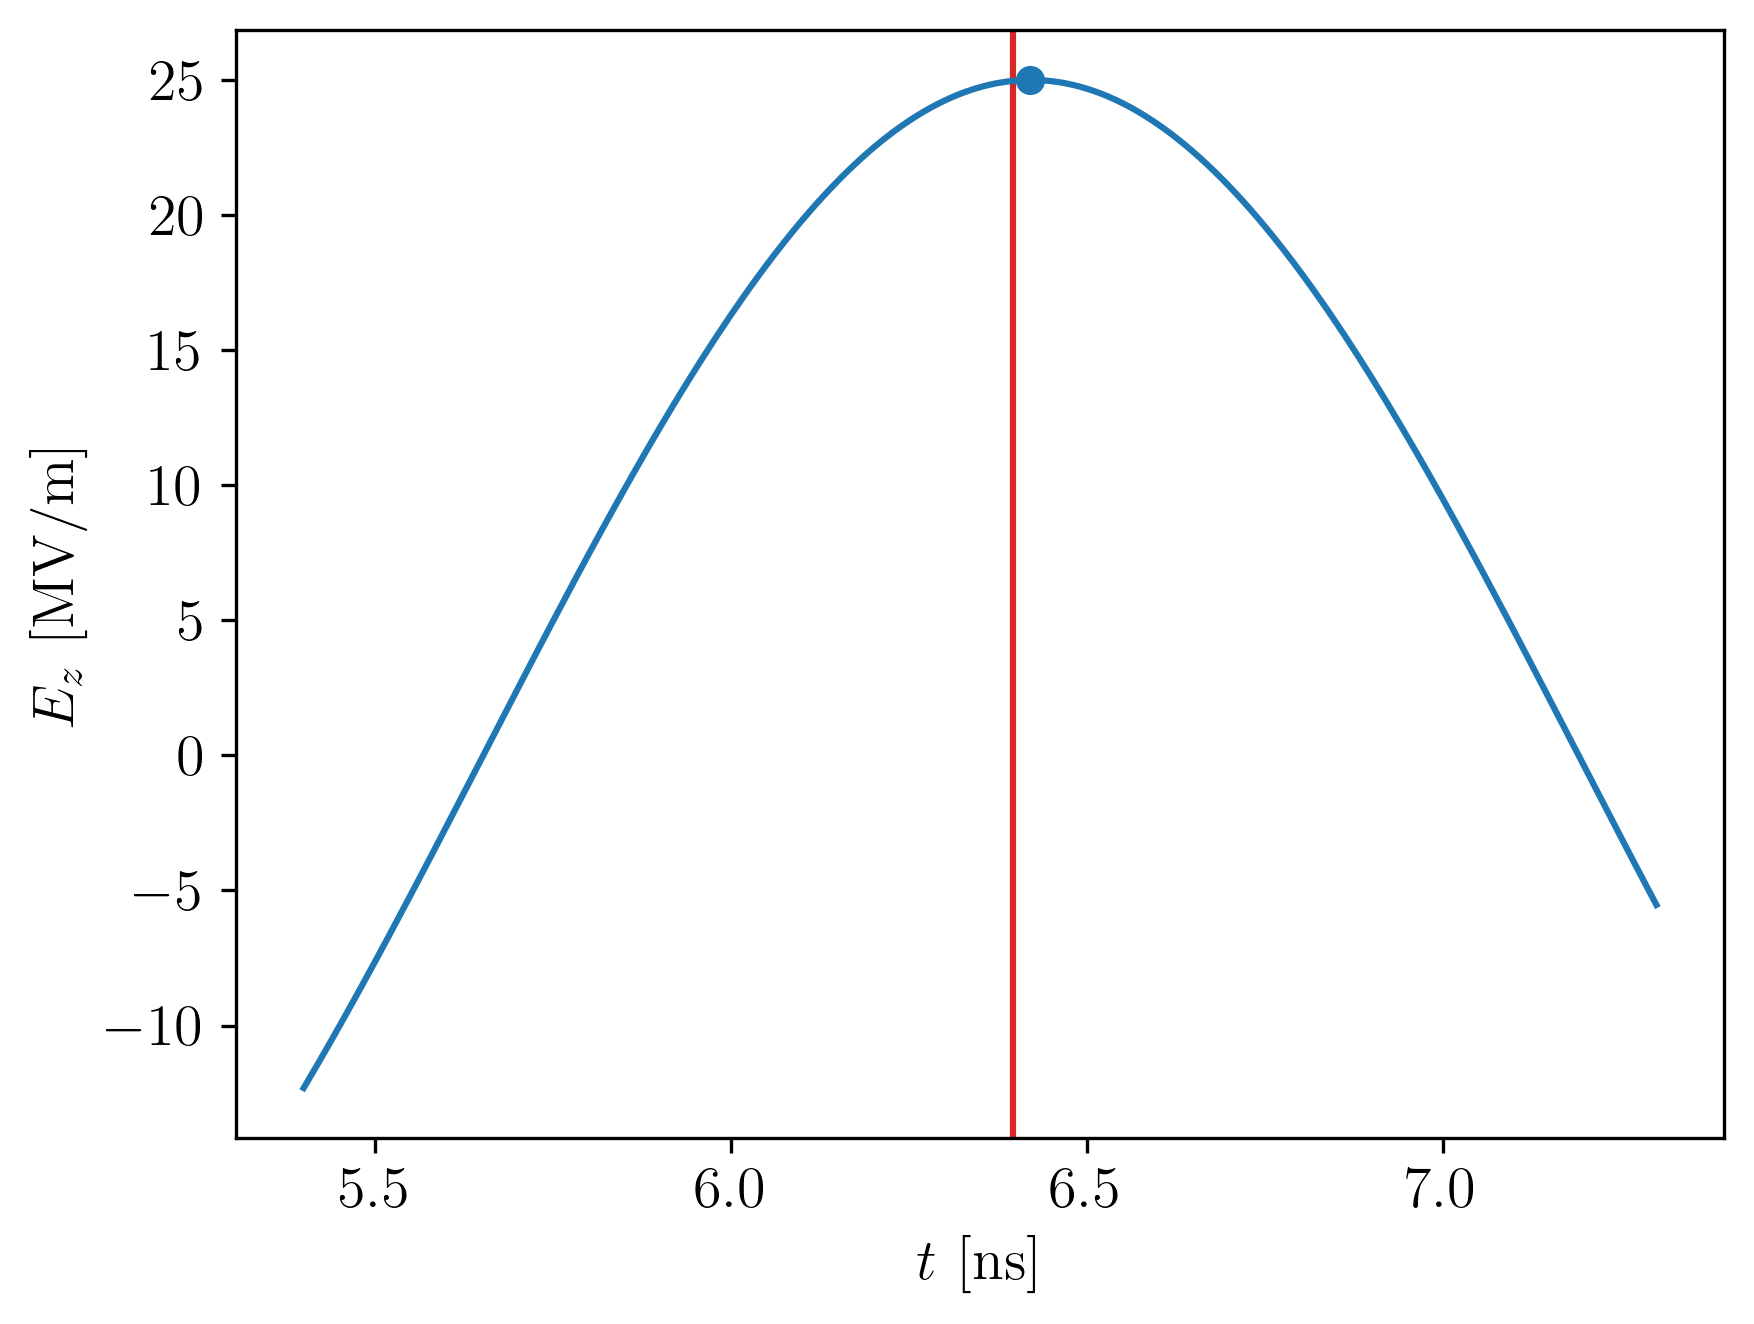

In [86]:
plt.plot(vals['t'],vals['Ez'])
plt.scatter(vals['t'][vals['Ez']==np.max(vals['Ez'])],np.max(vals['Ez']),label='max E')
plt.xlabel('$t$ [ns]')
plt.ylabel('$E_z$ [MV/m]')
plt.axvline(6.39688,zorder=-1,color='tab:red',label='reference particle at center of cavity');
# plt.legend()

In [77]:
np.max(vals['Ez'])

np.float64(24.9999)

In [79]:
vals['t']

0      5.40
1      5.41
2      5.42
3      5.43
4      5.44
       ... 
186    7.26
187    7.27
188    7.28
189    7.29
190    7.30
Name: t, Length: 191, dtype: float64

In [80]:
vals['Ez'][vals['t']==6.40]

100    24.9761
Name: Ez, dtype: float64

In [70]:
vals['t']

0      5.40
1      5.41
2      5.42
3      5.43
4      5.44
       ... 
186    7.26
187    7.27
188    7.28
189    7.29
190    7.30
Name: t, Length: 191, dtype: float64

In [71]:
np.where(vals['Ez'] > 0)

(array([ 26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
        143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
        156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
        169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179]),)